In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio

from astropy.io import fits
from astropy import wcs

from scipy.interpolate import RectBivariateSpline

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
# pixscale = 0.262

# img_fn = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/south/coadd/203/2036p022/legacysurvey-2036p022-maskbits.fits.fz'
# img_fn = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/north/coadd/148/1483p845/legacysurvey-1483p845-maskbits.fits.fz'
img_fn = '/global/cfs/cdirs/cosmo/staging/decam/CP/V4.8.2/CP20170330/c4d_170331_011148_ooi_r_ls9.fits.fz'
hdulist = fits.open(img_fn, hdu=1)

w = wcs.WCS(hdulist[1].header)
naxis1 = hdulist[1].header['NAXIS1']  # Length of the *second* index of the 2-D array
naxis2 = hdulist[1].header['NAXIS2']  # Length of the *first* index of the 2-D array

pix_x_grid, pix_y_grid = np.meshgrid(np.arange(naxis1), np.arange(naxis2))

In [4]:
%%time
pix_ra_true, pix_dec_true = w.wcs_pix2world(pix_x_grid, pix_y_grid, 0)

CPU times: user 2.58 s, sys: 298 ms, total: 2.88 s
Wall time: 2.88 s


In [5]:
%%time
# binsize = 1200
binsize = 1000
pix_x_spline, pix_y_spline = np.arange(-binsize, naxis1+2*binsize, binsize), np.arange(-binsize, naxis2+2*binsize, binsize)
xx, yy = np.meshgrid(pix_x_spline, pix_y_spline)
pix_ra_spline, pix_dec_spline = w.wcs_pix2world(xx, yy, 0)

interp_ra = RectBivariateSpline(pix_y_spline, pix_x_spline, pix_ra_spline)
interp_dec = RectBivariateSpline(pix_y_spline, pix_x_spline, pix_dec_spline)

pix_ra = interp_ra(np.arange(naxis2), np.arange(naxis1))
pix_dec = interp_dec(np.arange(naxis2), np.arange(naxis1))

CPU times: user 361 ms, sys: 71.1 ms, total: 432 ms
Wall time: 430 ms


3.55561979858976e-07
3.9239012039615773e-07


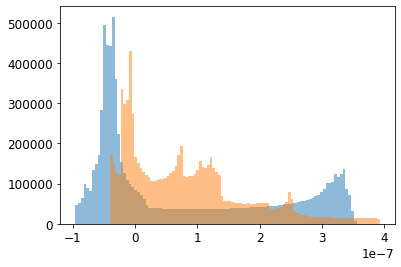

In [6]:
print(3600*np.max(np.abs(pix_dec_true - pix_dec)))
print(3600*np.max(np.abs(pix_ra_true - pix_ra)))

plt.hist((pix_dec - pix_dec_true).flatten() * 3600, 100, alpha=0.5)
plt.hist((pix_ra - pix_ra_true).flatten() * 3600, 100, alpha=0.5)
plt.show()

--------

In [20]:
cat = Table.read('/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/north/survey-bricks-dr9-north.fits.gz')

np.random.seed(512)
idx = np.random.choice(len(cat), size=int(1e2), replace=False)

ddec_list = []
dra_list = []

for index in idx:
    brickname = cat['brickname'][index]
    img_fn = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/north/coadd/{}/{}/legacysurvey-{}-maskbits.fits.fz'.format(brickname[:3], brickname, brickname)
    hdulist = fits.open(img_fn)
    
    w = wcs.WCS(hdulist[1].header)
    naxis1 = hdulist[1].header['NAXIS1']
    naxis2 = hdulist[1].header['NAXIS2']

    pix_x_grid, pix_y_grid = np.meshgrid(np.arange(naxis1), np.arange(naxis2))

    pix_ra_true, pix_dec_true = w.wcs_pix2world(pix_x_grid, pix_y_grid, 0)

    pix_x_spline, pix_y_spline = np.arange(0, naxis1+1, 1200), np.arange(0, naxis2+1, 1200)
    xx, yy = np.meshgrid(pix_x_spline, pix_y_spline)
    pix_ra_spline, pix_dec_spline = w.wcs_pix2world(xx, yy, 0)

    interp_ra = RectBivariateSpline(pix_x_spline, pix_y_spline, pix_ra_spline)
    interp_dec = RectBivariateSpline(pix_x_spline, pix_y_spline, pix_dec_spline)

    pix_ra = interp_ra(np.arange(naxis1), np.arange(naxis2))
    pix_dec = interp_dec(np.arange(naxis1), np.arange(naxis2))

    print(3600*np.max(np.abs(pix_dec_true - pix_dec)), 3600*np.max(np.abs(pix_ra_true - pix_ra)))

    ddec_list.append(3600*np.max(np.abs(pix_dec_true - pix_dec)))
    dra_list.append(3600*np.max(np.abs(pix_ra_true - pix_ra)))

2.0324478100519627e-06 1.0682015272323042e-07
1.919432293107093e-05 7.801554602338001e-06
1.93874996057275e-06 9.617906471248716e-08
3.635108214439242e-07 2.660272002685815e-09
5.254293000689358e-07 5.32054400537163e-09
1.0362111169115451e-08 2.2509993868879974e-09
3.8584175854339264e-07 3.4788172342814505e-09
3.9709163957013516e-06 4.229832484270446e-07
7.958050218803692e-07 1.2687451089732349e-08
4.930711838824209e-07 4.143885234952904e-09
4.098353656445397e-07 3.2741809263825417e-09
9.155428415397182e-07 1.7496404325356707e-08
7.498130116800894e-07 1.1254996934439987e-08
4.6900083816581173e-07 4.092726157978177e-09
5.322078777680872e-07 4.9112713895738125e-09
3.266251269451459e-07 2.148681232938543e-09
4.250040319675463e-07 3.6834535421803594e-09
2.4833639145072084e-06 1.6309513739543036e-07
3.384428737263079e-07 2.0463630789890885e-09
8.220649760914966e-06 1.6941839930950664e-06
8.867658607414342e-07 1.61662683240138e-08
6.118523288023425e-06 9.751943252922501e-07
5.18829779139196e

8.30523617878498e-05


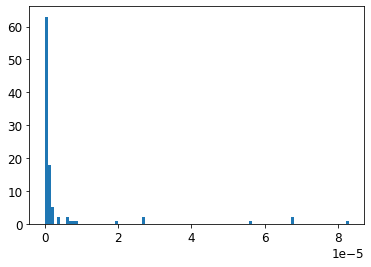

9.637531093176221e-05


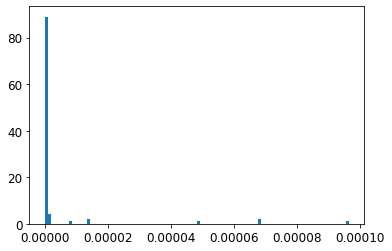

In [21]:
print(np.max(ddec_list))
plt.hist(ddec_list, 100)
plt.show()

print(np.max(dra_list))
plt.hist(dra_list, 100)
plt.show()